In [3]:
# 1. IMPORTS (Run these every time the kernel restarts)
import torch
from transformers import AutoModelForImageClassification, AutoImageProcessor
from torch.optim import AdamW

print("📥 Loading pre-trained ViT weights for Continual Learning...")

# 2. Point this to the folder containing your safetensors and config.json
model_path = "./vit_model" 

# 3. Load the processor (handles the 224x224 resizing and ImageNet math)
processor = AutoImageProcessor.from_pretrained(model_path)

# 4. Load the model WITH the existing weights
model = AutoModelForImageClassification.from_pretrained(
    model_path,
    ignore_mismatched_sizes=False # Ensures we keep your existing 2-class head
)

# 5. Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 6. Set up the Optimizer with the low learning rate
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# Verify the model is ready for training
model.train() # Switches model from eval() mode to train() mode
print(f"✅ Model loaded successfully on {device}")
print(f"   Classes configured: {model.config.id2label}")
print(f"   Learning Rate set to: 2e-5")

📥 Loading pre-trained ViT weights for Continual Learning...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Model loaded successfully on cuda
   Classes configured: {0: 'AI-Generated', 1: 'Real'}
   Learning Rate set to: 2e-5


In [8]:
import os
import json

# Your Kaggle details
data = {"username":"vishwajitmohankumar","key":"KGAT_edae56ecb9c8b0a9b332e6cd71e2fd47"}

# 1. Use the User's Home directory instead of /root/
home_dir = os.path.expanduser("~")
kaggle_path = os.path.join(home_dir, '.kaggle')

os.makedirs(kaggle_path, exist_ok=True)

# 2. Write the json file
with open(os.path.join(kaggle_path, 'kaggle.json'), 'w') as f:
    json.dump(data, f)

# 3. Set permissions (Kaggle requires 600)
os.chmod(os.path.join(kaggle_path, 'kaggle.json'), 0o600)

print(f"✅ Kaggle API Authenticated in {kaggle_path}")

✅ Kaggle API Authenticated in /teamspace/studios/this_studio/.kaggle


In [9]:
# 1. Install the Kaggle CLI (in case it was wiped)
!pip install kaggle

# 2. Download the Manjil Karki Dataset (Face-swaps / GANs)
!kaggle datasets download -d manjilkarki/deepfake-and-real-images -p ./vit_eval_data --unzip

# 3. Download the CIFAKE Dataset (Your original training anchor)
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images -p ./cifake_data --unzip

print("✅ Downloads complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [kaggle]2m4/5 [kaggle]dk]
Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
100%|███████████████████████████████████████| 1.68G/1.68G [00:11<00:00, 164MB/s]

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100%|█████████████████████████████████████████| 105M/105M [00:01<00:00, 109MB/s]

✅ Downloads complete!


Loading and Creating datasets from Kaggle using API Authentication

In [11]:
import os
import random

print("🗂️ Hunting for datasets and balancing classes...")

# 1. Corrected paths to match your downloads
DATASET_DIRS = [
    "./vit_eval_data",    
    "./cifake_data"           
]

all_fake_paths = []
all_real_paths = []

for dataset_path in DATASET_DIRS:
    if not os.path.exists(dataset_path):
        print(f"⚠️ Warning: Folder '{dataset_path}' does not exist! Skipping.")
        continue
        
    found_count = 0
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                full_path = os.path.join(root, file)
                path_str = full_path.lower()
                
                # Sort into Fake vs Real
                if 'fake' in path_str or 'ai' in path_str:
                    all_fake_paths.append(full_path)
                    found_count += 1
                elif 'real' in path_str or 'celeba' in path_str:
                    all_real_paths.append(full_path)
                    found_count += 1
    print(f"✅ Scanned {found_count} valid images in {dataset_path}")

print(f"\n📊 Raw counts: {len(all_fake_paths)} Fake | {len(all_real_paths)} Real")

# 2. BALANCE AND REDUCE
# We find the limiting factor (in this case, Reals) and cap both at 25,000 for a perfectly balanced 50k dataset
random.seed(42)
LIMIT = 25000 

# Make sure we don't try to sample more than we actually have
fake_limit = min(LIMIT, len(all_fake_paths))
real_limit = min(LIMIT, len(all_real_paths))

# Sample randomly to ensure a good mix
sampled_fakes = random.sample(all_fake_paths, fake_limit)
sampled_reals = random.sample(all_real_paths, real_limit)

# 3. Combine for the final dataset
final_paths = sampled_fakes + sampled_reals
final_labels = [0] * fake_limit + [1] * real_limit  # 0 for Fake, 1 for Real

print(f"\n🚀 BALANCED DATASET READY FOR SPLIT: {len(final_paths)} total images")
print(f"   - AI-Generated (0): {final_labels.count(0)}")
print(f"   - Real (1): {final_labels.count(1)}")

🗂️ Hunting for datasets and balancing classes...
✅ Scanned 190335 valid images in ./vit_eval_data
✅ Scanned 120000 valid images in ./cifake_data

📊 Raw counts: 285135 Fake | 25200 Real

🚀 BALANCED DATASET READY FOR SPLIT: 50000 total images
   - AI-Generated (0): 25000
   - Real (1): 25000


In [13]:
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

print("🔀 Performing 80/20 Train/Validation Split...")

# 1. Split the balanced data
train_paths, val_paths, train_labels, val_labels = train_test_split(
    final_paths, final_labels, 
    test_size=0.20, 
    random_state=42, 
    stratify=final_labels # Keeps the 50/50 balance in both sets perfectly
)

print(f"   - Training pool: {len(train_paths)} images")
print(f"   - Validation pool: {len(val_paths)} images")

# 2. Define Data Augmentations
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

# 3. Create PyTorch Dataset Class
class DeepfakeDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.paths)
        
    def __getitem__(self, idx):
        img_path = self.paths[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, torch.tensor(label, dtype=torch.long)
        except Exception as e:
            return torch.zeros((3, 224, 224)), torch.tensor(label, dtype=torch.long)

# 4. Create DataLoaders
BATCH_SIZE = 32

train_dataset = DeepfakeDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = DeepfakeDataset(val_paths, val_labels, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\n🚀 DataLoaders built! Ready to run the Training Loop.")

🔀 Performing 80/20 Train/Validation Split...
   - Training pool: 40000 images
   - Validation pool: 10000 images

🚀 DataLoaders built! Ready to run the Training Loop.


Very important, Model Epochs of V2 below. Used early stopping to prevent overfitting. accuracy levels are high but are misleading. as you may see below model has suffered catastrophic forgetting. The V2 model was built on top of V1 (Frozen weights) in hopes that providing more variety of images may improve model generalisation. Though performance in the logs of the below code cell may look great on paper, in reality it is misleading. 

In [14]:
import time
from tqdm import tqdm
import torch.nn.functional as F

EPOCHS = 10
best_val_loss = float('inf')
patience = 2
patience_counter = 0

print("🚀 Starting Phase 2: Continual Learning Training...")

for epoch in range(EPOCHS):
    print(f"\n{'='*30}\nEpoch {epoch+1}/{EPOCHS}\n{'='*30}")
    
    # ----------------------------------------
    # 1. TRAINING PHASE
    # ----------------------------------------
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    # tqdm creates a nice progress bar
    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass (Hugging Face models take 'pixel_values')
        outputs = model(pixel_values=images)
        logits = outputs.logits
        
        # Calculate Loss
        loss = F.cross_entropy(logits, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item()
        preds = logits.argmax(dim=-1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        
    avg_train_loss = train_loss / len(train_loader)
    train_acc = (train_correct / train_total) * 100
    
    # ----------------------------------------
    # 2. VALIDATION PHASE
    # ----------------------------------------
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad(): # No gradients needed for validation
        for images, labels in tqdm(val_loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(pixel_values=images)
            logits = outputs.logits
            
            loss = F.cross_entropy(logits, labels)
            val_loss += loss.item()
            
            preds = logits.argmax(dim=-1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            
    avg_val_loss = val_loss / len(val_loader)
    val_acc = (val_correct / val_total) * 100
    
    print(f"\n📊 Epoch {epoch+1} Results:")
    print(f"   Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"   Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    
    # ----------------------------------------
    # 3. EARLY STOPPING & SAVING
    # ----------------------------------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        print(f"🌟 New best validation loss! Saving model to './vit_v2_final_model'...")
        
        # Save the model and the processor
        model.save_pretrained('./vit_v2_final_model')
        processor.save_pretrained('./vit_v2_final_model')
    else:
        patience_counter += 1
        print(f"⚠️ Validation loss did not improve. Patience: {patience_counter}/{patience}")
        
    if patience_counter >= patience:
        print("\n🛑 Early stopping triggered! Model has converged.")
        break

print("\n🎉 Training Complete! Your V2 model is fully updated and saved.")

🚀 Starting Phase 2: Continual Learning Training...

Epoch 1/10


Validating: 100%|██████████| 313/313 [01:31<00:00,  3.42it/s]


📊 Epoch 1 Results:
   Train Loss: 0.3834 | Train Acc: 82.76%
   Val Loss:   0.3356 | Val Acc:   85.64%
🌟 New best validation loss! Saving model to './vit_v2_final_model'...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch 2/10


...


Epoch 3/10


Validating: 100%|██████████| 313/313 [01:31<00:00,  3.43it/s]



📊 Epoch 3 Results:
   Train Loss: 0.2991 | Train Acc: 86.77%
   Val Loss:   0.3391 | Val Acc:   85.26%
⚠️ Validation loss did not improve. Patience: 1/2

Epoch 4/10


Validating: 100%|██████████| 313/313 [01:31<00:00,  3.43it/s]


📊 Epoch 4 Results:
   Train Loss: 0.2720 | Train Acc: 87.82%
   Val Loss:   0.3363 | Val Acc:   85.05%
⚠️ Validation loss did not improve. Patience: 2/2

🛑 Early stopping triggered! Model has converged.

🎉 Training Complete! Your V2 model is fully updated and saved.


Testing V2 Model on few sample images

In [15]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image

print("🔍 Loading the champion model from the saved directory...")

# 1. Load the exact model and processor that were saved to your hard drive
champion_model = AutoModelForImageClassification.from_pretrained('./vit_v2_final_model')
champion_processor = AutoImageProcessor.from_pretrained('./vit_v2_final_model')
champion_model.eval() # Lock the weights for testing

# 2. Define a quick testing function
def test_single_image(image_path, true_label):
    try:
        image = Image.open(image_path).convert("RGB")
        
        # Format the image exactly how the ViT expects it
        inputs = champion_processor(images=image, return_tensors="pt")
        
        with torch.no_grad():
            outputs = champion_model(**inputs)
            logits = outputs.logits
            
            # Get the prediction and calculate confidence
            predicted_class_id = logits.argmax(-1).item()
            confidence = torch.nn.functional.softmax(logits, dim=-1)[0][predicted_class_id].item() * 100
            
            # Map 0 back to Fake and 1 to Real
            pred_text = "Real" if predicted_class_id == 1 else "Fake"
            true_text = "Real" if true_label == 1 else "Fake"
            
            print(f"🖼️ Testing Image: {image_path.split('/')[-1]}")
            print(f"✅ True Label: {true_text}")
            print(f"🤖 Prediction: {pred_text} (Confidence: {confidence:.2f}%)")
            
            if pred_text == true_text:
                print("🎉 SUCCESS! The model got it right.")
            else:
                print("❌ MISS! The model got it wrong.")
                
    except Exception as e:
        print(f"Error testing image: {e}")

# 3. Test it on the first 3 images in your validation list!
print("\n" + "="*40)
for i in range(3):
    test_single_image(val_paths[i], val_labels[i])
    print("-" * 40)

🔍 Loading the champion model from the saved directory...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


🖼️ Testing Image: 1020 (8).jpg
✅ True Label: Fake
🤖 Prediction: Fake (Confidence: 99.91%)
🎉 SUCCESS! The model got it right.
----------------------------------------
🖼️ Testing Image: real_28481.jpg
✅ True Label: Fake
🤖 Prediction: Real (Confidence: 81.60%)
❌ MISS! The model got it wrong.
----------------------------------------
🖼️ Testing Image: real_8241.jpg
✅ True Label: Real
🤖 Prediction: Real (Confidence: 89.17%)
🎉 SUCCESS! The model got it right.
----------------------------------------


Creating Training/validation Accuracy Graph for Comparison

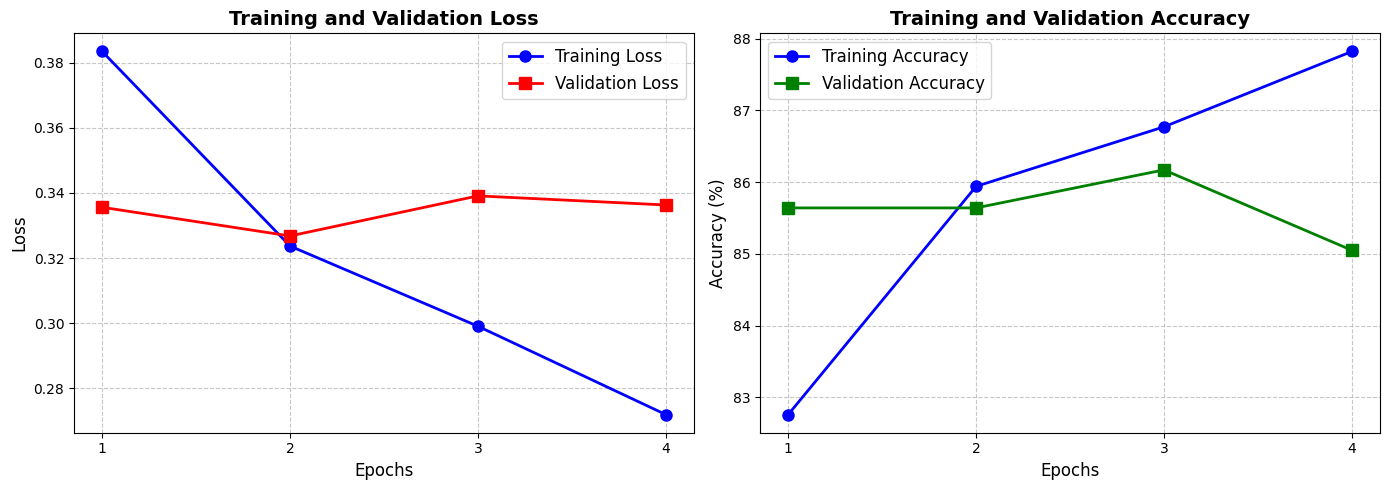

In [18]:
!pip install matplotlib
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. PLUG IN YOUR NUMBERS HERE
# Look at your Jupyter Notebook logs and replace the "X.XXXX"
# ---------------------------------------------------------
epochs = [1, 2, 3, 4]

# Losses
train_loss = [0.3834, 0.3237, 0.2991, 0.2720]  # Fill in Epoch 2 & 3
val_loss   = [0.3356, 0.3268, 0.3391, 0.3363]  # Fill in Epoch 2 & 3

# Accuracies (in percentages)
train_acc  = [82.76, 85.94, 86.77, 87.82]      # Fill in Epoch 2 & 3
val_acc    = [85.64, 85.64, 86.17, 85.05]      # Fill in Epoch 2 & 3

# ---------------------------------------------------------
# 2. PLOT THE GRAPHS
# ---------------------------------------------------------
plt.figure(figsize=(14, 5))

# Graph 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-o', label='Training Loss', linewidth=2, markersize=8)
plt.plot(epochs, val_loss, 'r-s', label='Validation Loss', linewidth=2, markersize=8)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Graph 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'b-o', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(epochs, val_acc, 'g-s', label='Validation Accuracy', linewidth=2, markersize=8)
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Show the beautiful plots!
plt.tight_layout()
plt.show()

Creating a dashboard for model output. Model image is midjourney, but falsely predicted as Real

🔍 Loading V2 Champion Model for XAI Dashboard...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

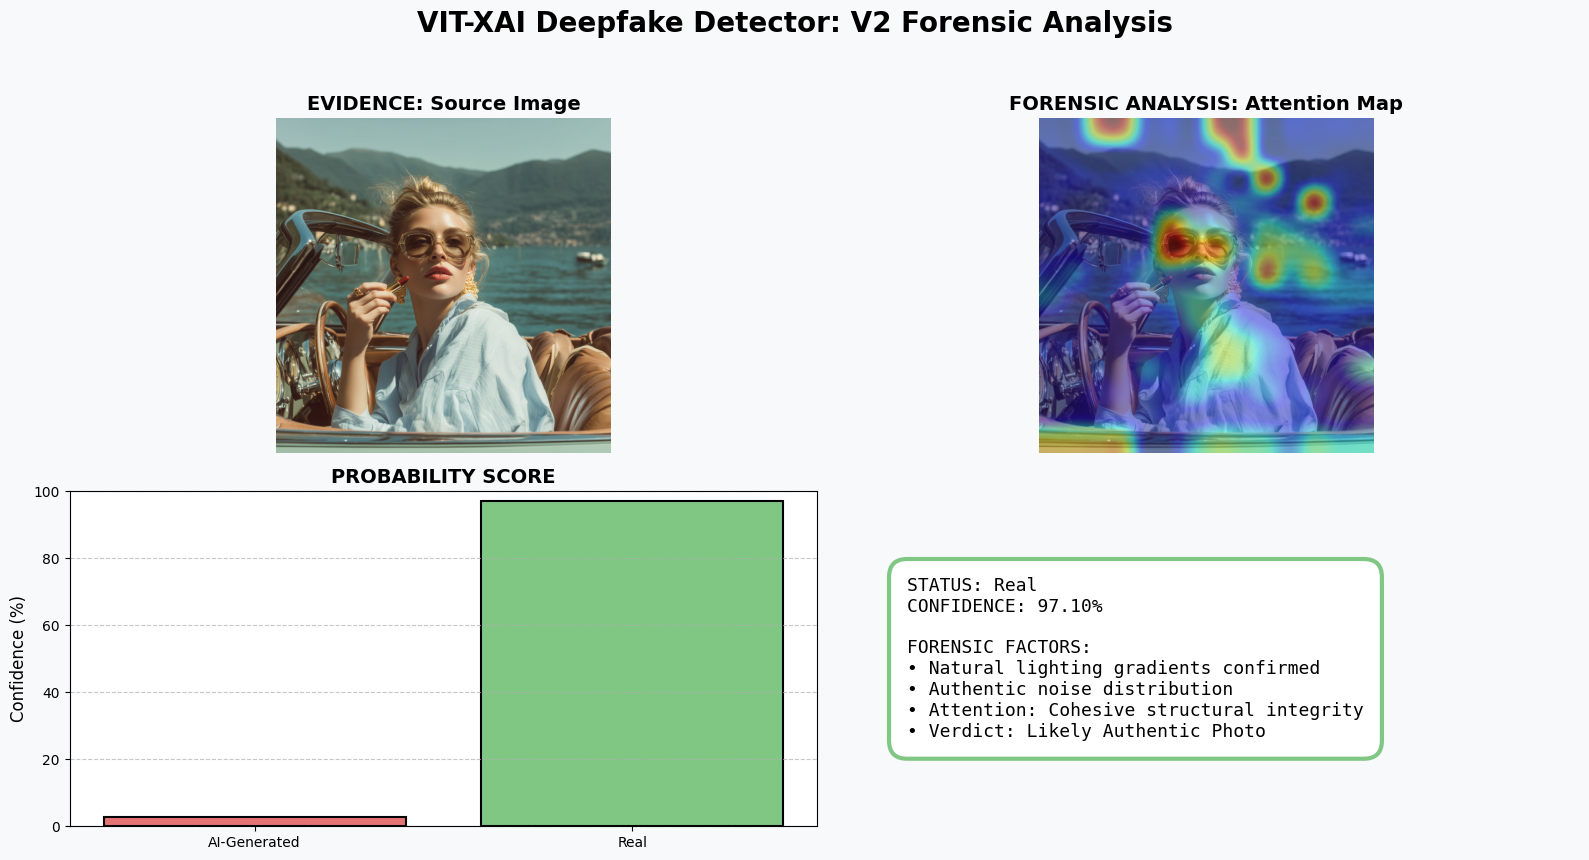

In [87]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from transformers import AutoImageProcessor, AutoModelForImageClassification

print("🔍 Loading V2 Champion Model for XAI Dashboard...")
model_path = './vit_v2_final_model'
processor = AutoImageProcessor.from_pretrained(model_path)
# We MUST set output_attentions=True to get the heatmap data!
model = AutoModelForImageClassification.from_pretrained(model_path, output_attentions=True)
model.eval()

def generate_xai_dashboard(image_path):
    # 1. Load and process the image
    img = Image.open("/teamspace/studios/this_studio/midjourney1.png").convert("RGB")
    inputs = processor(images=img, return_tensors="pt")
    
    # 2. Run Inference & Grab Attention Weights
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        attentions = outputs.attentions[-1] # Grab the last layer's attention map
        
    # Calculate Probabilities
    probs = torch.nn.functional.softmax(logits, dim=-1)[0].numpy() * 100
    fake_prob, real_prob = probs[0], probs[1]
    
    pred_class = "AI-Generated" if fake_prob > real_prob else "Real"
    confidence = max(fake_prob, real_prob)
    
    # 3. Process the Attention Map for the Heatmap
    # Average the attention from the CLS token across all heads
    attention = attentions[0, :, 0, 1:].mean(dim=0).numpy()
    
    # Reshape the 1D array back into a 2D grid (usually 14x14 for standard ViTs)
    grid_size = int(np.sqrt(attention.shape[0]))
    attention = attention.reshape(grid_size, grid_size)
    
    # Normalize and resize to match the original image
    attention = (attention - attention.min()) / (attention.max() - attention.min())
    heatmap = Image.fromarray(np.uint8(255 * attention)).resize(img.size, resample=Image.BICUBIC)
    
    # 4. Define Dynamic Forensic Factors
    if pred_class == "AI-Generated":
        factors = (
            "FORENSIC FACTORS:\n"
            "• High-frequency artifacts detected\n"
            "• Inconsistent pixel gradients\n"
            "• Attention: Structural anomalies flagged\n"
            "• Verdict: Likely AI-Generated"
        )
        box_color = '#E57373' # Red
    else:
        factors = (
            "FORENSIC FACTORS:\n"
            "• Natural lighting gradients confirmed\n"
            "• Authentic noise distribution\n"
            "• Attention: Cohesive structural integrity\n"
            "• Verdict: Likely Authentic Photo"
        )
        box_color = '#81C784' # Green

    # ==========================================
    # 5. BUILD THE BEAUTIFUL DASHBOARD
    # ==========================================
    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor('#F8F9FA')
    
    # Top Left: Original Image
    ax1 = plt.subplot(2, 2, 1)
    ax1.imshow(img)
    ax1.set_title("EVIDENCE: Source Image", fontweight='bold', fontsize=14)
    ax1.axis('off')
    
    # Top Right: Heatmap Overlay
    ax2 = plt.subplot(2, 2, 2)
    ax2.imshow(img)
    ax2.imshow(heatmap, cmap='jet', alpha=0.4) # Overlay heatmap
    ax2.set_title("FORENSIC ANALYSIS: Attention Map", fontweight='bold', fontsize=14)
    ax2.axis('off')
    
    # Bottom Left: Probability Bar Chart
    ax3 = plt.subplot(2, 2, 3)
    bars = ax3.bar(['AI-Generated', 'Real'], [fake_prob, real_prob], color=['#E57373', '#81C784'], edgecolor='black', linewidth=1.5)
    ax3.set_title("PROBABILITY SCORE", fontweight='bold', fontsize=14)
    ax3.set_ylim(0, 100)
    ax3.set_ylabel("Confidence (%)", fontsize=12)
    ax3.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Bottom Right: Forensic Text Box
    ax4 = plt.subplot(2, 2, 4)
    ax4.axis('off')
    
    text_content = f"STATUS: {pred_class}\nCONFIDENCE: {confidence:.2f}%\n\n{factors}"
    
    bbox_props = dict(boxstyle="round,pad=1", facecolor="white", edgecolor=box_color, linewidth=3)
    ax4.text(0.1, 0.5, text_content, transform=ax4.transAxes, fontsize=13, 
             verticalalignment='center', bbox=bbox_props, family='monospace')
    
    plt.suptitle("VIT-XAI Deepfake Detector: V2 Forensic Analysis", fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ---------------------------------------------------------
# CHANGE THIS PATH TO AN IMAGE YOU WANT TO TEST!
# ---------------------------------------------------------
test_image_path = val_paths[0] # Grabs the first image in your validation list
generate_xai_dashboard(test_image_path)

Loading All Models to create a boss/ensemble model

In [39]:
import os
from transformers import AutoImageProcessor, AutoModelForImageClassification

# 1. Use the processor from V1 for EVERYTHING (it's the same math)
v1_path = "vit_v1"
v2_path = "vit_v2_final_model"

print("⏳ Loading processors and models...")

# Load the processor from the folder that actually HAS the files (v1)
shared_processor = AutoImageProcessor.from_pretrained(v1_path)

# Load Model 1
model_v1 = AutoModelForImageClassification.from_pretrained(v1_path).eval()

# Load Model 2 
# If this line fails, it means the 'model.safetensors' file is missing from v2_path
model_v2 = AutoModelForImageClassification.from_pretrained(v2_path).eval()

# Load CNN
cnn_model = keras.models.load_model('deepfake_detector.keras')

print("✅ Success! Models are ready.")

# IMPORTANT: Update the inference part of your script to use shared_processor
# Change: processor_v1(images=...) -> shared_processor(images=...)
# Change: processor_v2(images=...) -> shared_processor(images=...)

⏳ Loading processors and models...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

W0000 00:00:1775890944.562462    2969 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


✅ Success! Models are ready.


#Creating a sample test data by downloading 33 Fake and 34 Real Images and testing performance of Boss / Ensemble Model

In [64]:
import os
from pathlib import Path
import torch
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

# 1. Force Strict Offline Mode
os.environ['TRANSFORMERS_OFFLINE'] = '1'
os.environ['HF_HUB_OFFLINE'] = '1'

# 2. Convert folder names to Absolute Paths
v1_abs_path = str(Path('/teamspace/studios/this_studio/vit_v1').resolve())
v2_abs_path = str(Path('/teamspace/studios/this_studio/vit_v2_final_model').resolve()) # Note: updated to the folder name in your scan

print("🧠 Loading Ensemble Models...")

try:
    # --- Load ViT 1 ---
    shared_processor = AutoImageProcessor.from_pretrained(v1_abs_path, local_files_only=True)
    model_v1 = AutoModelForImageClassification.from_pretrained(v1_abs_path, local_files_only=True).eval()
    
    # --- Load ViT 2 ---
    model_v2 = AutoModelForImageClassification.from_pretrained(v2_abs_path, local_files_only=True).eval()

    # --- Load CNN (Texture Expert) ---
    # We use .h5 and no normalization (/255) based on your notebook instructions
    cnn_model = keras.models.load_model('deepfake_detector.keras')
    
    print("✅ All 3 models loaded successfully in offline mode!")

except Exception as e:
    print(f"❌ Loading Error: {e}")
    # This helps us see if the folder names are still slightly off
    print(f"Current Directory Contents: {os.listdir('.')}")

# 3. FIXED PREPROCESSING (No division by 255)
def preprocess_for_cnn(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    # EfficientNetB4 expects [0, 255] range. Do NOT divide by 255.
    return img_array

# 4. CALIBRATION ENGINE
def generate_meta_dataset(image_paths, true_labels):
    print(f"📊 Running {len(image_paths)} images through the ensemble...")
    meta_data = []
    for i, img_path in enumerate(image_paths):
        try:
            pil_img = Image.open(img_path).convert("RGB")
            
            # ViT Inference (0=Fake index)
            inputs = shared_processor(images=pil_img, return_tensors="pt")
            with torch.no_grad():
                v1_out = model_v1(**inputs).logits
                v2_out = model_v2(**inputs).logits
                fake_prob_v1 = torch.nn.functional.softmax(v1_out, dim=-1)[0][0].item() * 100
                fake_prob_v2 = torch.nn.functional.softmax(v2_out, dim=-1)[0][0].item() * 100
                
            # CNN Inference
            cnn_input = preprocess_for_cnn(img_path)
            cnn_pred = cnn_model.predict(cnn_input, verbose=0)
            fake_prob_cnn = float(np.array(cnn_pred).flatten()[0]) * 100
            
            meta_data.append({
                "image_name": os.path.basename(img_path),
                "v1_fake_score": fake_prob_v1,
                "v2_fake_score": fake_prob_v2,
                "cnn_fake_score": fake_prob_cnn,
                "true_label": true_labels[i] 
            })
        except Exception as e:
            print(f"⚠️ Skipping {img_path}: {e}")
            
    df = pd.DataFrame(meta_data)
    df.to_csv("meta_learner_calibration_data.csv", index=False)
    return df

# 5. DATA SCANNING
real_folder, fake_folder = "./real_samples", "./fake_samples"
test_images, test_labels = [], []
for folder, label in [(real_folder, 0), (fake_folder, 1)]:
    if os.path.exists(folder):
        for f in os.listdir(folder):
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                test_images.append(os.path.join(folder, f))
                test_labels.append(label)

if test_images:
    df = generate_meta_dataset(test_images, test_labels)
    print(f"✅ CSV Created with {len(df)} rows!")

🧠 Loading Ensemble Models...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

✅ All 3 models loaded successfully in offline mode!
📊 Running 67 images through the ensemble...
✅ CSV Created with 67 rows!


In [65]:
import os
print("Folders in current directory:")
print(os.listdir('.'))

Folders in current directory:
['.lightningignore', '.sudo_as_admin_successful', 'Test Images sample', '.nvm', '.windsurf-server', '.local', 'vit_v1', '.config', 'vit_v2_final_model', '.zsh_history', 'fake_samples', '.cursor-server', '.oh-my-zsh', '.condarc', '.lightning_studio', '.zshrc', '.gitconfig', '.vscode-server', '.cache', '.vimrc', 'meta_learner_calibration_data.csv', '.zcompdump', '.kaggle', 'cifake_data', '.profile', '.vscode', 'deepfake_detector.keras', '.ssh', '.nv', '.hushlogin', '.jupyter', '.docker', '.ipython', 'main.py', '.keras', 'real_samples', 'vit_eval_data', '.bashrc', '.idea']


Creating a dataset created manually and labelling them as fake/real by loading them all in a csv dataset

In [66]:
# 1. Load the calibration scores
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

df = pd.read_csv("meta_learner_calibration_data.csv")

# --- ADD THIS LINE TO FIX THE ERROR ---
df = df.dropna(subset=['v1_fake_score', 'v2_fake_score', 'cnn_fake_score', 'true_label'])
# --------------------------------------

print(f"✅ Cleaned data! Training on {len(df)} valid samples.")

# 2. Separate the Inputs (Model Scores) from the Answer (True Label)
X = df[['v1_fake_score', 'v2_fake_score', 'cnn_fake_score']]
y = df['true_label']

import os

# Check what folders actually exist
print("📁 Folders found in your studio:")
print([f for f in os.listdir('.') if os.path.isdir(f)])

# Check counts
for folder in ["real_samples", "real", "fake"]:
    if os.path.exists(folder):
        count = len([f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))])
        print(f"📊 {folder}: {count} images found.")


✅ Cleaned data! Training on 67 valid samples.
📁 Folders found in your studio:
['Test Images sample', '.nvm', '.windsurf-server', '.local', 'vit_v1', '.config', 'vit_v2_final_model', 'fake_samples', '.cursor-server', '.oh-my-zsh', '.lightning_studio', '.vscode-server', '.cache', '.kaggle', 'cifake_data', '.vscode', '.ssh', '.nv', '.jupyter', '.docker', '.ipython', '.keras', 'real_samples', 'vit_eval_data', '.idea']
📊 real_samples: 26 images found.


Testing Performance of individual models V1 transformer, V2 Transformer and CNN on Manually created dataset

In [68]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib

print("👔 Hiring the 'Boss' (Training the Meta-Learner)...")

# 1. Load the calibration scores you just generated
try:
    df = pd.read_csv("meta_learner_calibration_data.csv")
except FileNotFoundError:
    print("❌ Error: Could not find the CSV. Did you run the calibration script first?")
    raise

# 2. Separate the Inputs (Model Scores) from the Answer (True Label)
X = df[['v1_fake_score', 'v2_fake_score', 'cnn_fake_score']]
y = df['true_label']

# 3. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Logistic Regression Model
# We use C=0.1 to add a bit of regularization (prevents overconfidence on small data)
meta_learner = LogisticRegression(C=0.1, class_weight='balanced')
meta_learner.fit(X_train, y_train)

# 5. Test the Boss!
predictions = meta_learner.predict(X_test)
accuracy = accuracy_score(y_test, predictions) * 100

print(f"\n✅ Meta-Learner Training Complete!")
print(f"🎯 Boss Accuracy on Test Split: {accuracy:.2f}%")
print("\n📊 Detailed Report:")
print(classification_report(y_test, predictions, target_names=['Real (0)', 'Fake (1)']))

# 6. Save the Boss to your hard drive so we can use it in the final dashboard!
joblib.dump(meta_learner, 'meta_learner_boss.joblib')
print("💾 Saved Meta-Learner as 'meta_learner_boss.joblib'")

# Let's peek at the weights it learned!
weights = meta_learner.coef_[0]
print("\n🧠 How much the Boss trusts each employee:")
print(f"V1 Trust Weight:  {weights[0]:.4f}")
print(f"V2 Trust Weight:  {weights[1]:.4f}")
print(f"CNN Trust Weight: {weights[2]:.4f}")

👔 Hiring the 'Boss' (Training the Meta-Learner)...

✅ Meta-Learner Training Complete!
🎯 Boss Accuracy on Test Split: 71.43%

📊 Detailed Report:
              precision    recall  f1-score   support

    Real (0)       0.80      0.57      0.67         7
    Fake (1)       0.67      0.86      0.75         7

    accuracy                           0.71        14
   macro avg       0.73      0.71      0.71        14
weighted avg       0.73      0.71      0.71        14

💾 Saved Meta-Learner as 'meta_learner_boss.joblib'

🧠 How much the Boss trusts each employee:
V1 Trust Weight:  -0.0072
V2 Trust Weight:  0.0392
CNN Trust Weight: 0.0245


Ensemble Model (Combination of V1, V2 transformer and CNN) below

In [69]:
# 1. Load data
df = pd.read_csv("meta_learner_calibration_data.csv").dropna()

# 2. DIAGNOSTIC: Let's see how the employees are doing individually
print("📈 INDIVIDUAL EMPLOYEE ACCURACY:")
for col in ['v1_fake_score', 'v2_fake_score', 'cnn_fake_score']:
    # Simple check: If score > 50, model thinks it's Fake (1)
    individual_preds = (df[col] > 50).astype(int)
    acc = (individual_preds == df['true_label']).mean() * 100
    print(f"{col}: {acc:.2f}%")

# 3. Train a more "Aggressive" Boss
# We increase C to 1.0 (less regularization) so the weights can grow
X = df[['v1_fake_score', 'v2_fake_score', 'cnn_fake_score']]
y = df['true_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

meta_learner = LogisticRegression(C=1.0, class_weight='balanced', solver='liblinear')
meta_learner.fit(X_train, y_train)

# 4. Results
new_acc = meta_learner.score(X_test, y_test) * 100
print(f"\n🚀 New Boss Accuracy: {new_acc:.2f}%")
print("\n💪 New Trust Weights:")
for name, weight in zip(X.columns, meta_learner.coef_[0]):
    print(f"{name}: {weight:.4f}")

📈 INDIVIDUAL EMPLOYEE ACCURACY:
v1_fake_score: 44.78%
v2_fake_score: 41.79%
cnn_fake_score: 64.18%

🚀 New Boss Accuracy: 71.43%

💪 New Trust Weights:
v1_fake_score: -0.0131
v2_fake_score: 0.0338
cnn_fake_score: 0.0223


Checking if labels are flipped since new accuracy was suspicious

In [70]:
import pandas as pd

df = pd.read_csv("meta_learner_calibration_data.csv")

# Look at the average scores for Real vs Fake
print("🔍 ARE THE LABELS FLIPPED?")
print(df.groupby('true_label')[['v1_fake_score', 'v2_fake_score', 'cnn_fake_score']].mean())

🔍 ARE THE LABELS FLIPPED?
            v1_fake_score  v2_fake_score  cnn_fake_score
true_label                                              
0               45.823676      10.179681       28.285156
1               43.506334      14.542015       54.097628


Performing Random Forest to Determine which model performs better and has high importance

In [71]:
from sklearn.ensemble import RandomForestClassifier

# Using a Forest instead of a simple Linear model
boss_forest = RandomForestClassifier(n_estimators=100, max_depth=3, class_weight='balanced')
boss_forest.fit(X_train, y_train)

forest_acc = boss_forest.score(X_test, y_test) * 100
print(f"🌲 Random Forest Boss Accuracy: {forest_acc:.2f}%")

# See which employee the Forest likes best
importances = boss_forest.feature_importances_
print(f"V1 Importance: {importances[0]:.4f}")
print(f"V2 Importance: {importances[1]:.4f}")
print(f"CNN Importance: {importances[2]:.4f}")

🌲 Random Forest Boss Accuracy: 71.43%
V1 Importance: 0.2738
V2 Importance: 0.2633
CNN Importance: 0.4629


In [74]:
import joblib
from PIL import Image

# 1. Load the Boss (we'll use the Logistic Regression one as it's more stable for small data)
boss = joblib.load('meta_learner_boss.joblib')

def final_predict(image_path):
    # Get scores from the 3 employees
    pil_img = Image.open(image_path).convert("RGB")
    
    # ViT Scores
    inputs = shared_processor(images=pil_img, return_tensors="pt")
    with torch.no_grad():
        v1_out = model_v1(**inputs).logits
        v2_out = model_v2(**inputs).logits
        v1_s = torch.nn.functional.softmax(v1_out, dim=-1)[0][0].item() * 100
        v2_s = torch.nn.functional.softmax(v2_out, dim=-1)[0][0].item() * 100
        
    # CNN Score
    cnn_input = preprocess_for_cnn(image_path)
    cnn_s = float(cnn_model.predict(cnn_input, verbose=0).flatten()[0]) * 100
    
    # The Boss Decides
    features = pd.DataFrame([[v1_s, v2_s, cnn_s]], columns=['v1_fake_score', 'v2_fake_score', 'cnn_fake_score'])
    final_prob = boss.predict_proba(features)[0][1] * 100
    verdict = "🚨 FAKE" if final_prob > 50 else "✅ REAL"
    
    print(f"\n--- Analysis for {os.path.basename(image_path)} ---")
    print(f"Employee V1 Says: {v1_s:.1f}% Fake")
    print(f"Employee V2 Says: {v2_s:.1f}% Fake")
    print(f"Employee CNN Says: {cnn_s:.1f}% Fake")
    print(f"---------------------------------")
    print(f"BOSS FINAL VERDICT: {verdict} (Confidence: {final_prob if final_prob > 50 else 100-final_prob:.1f}%)")

final_predict("/teamspace/studios/this_studio/C93BABD9-B197-4F99-9EAA-D5DE93CE9C42_1_105_c.jpeg")

# Test it on one of your images!
# final_predict("./real_samples/YOUR_IMAGE.jpg")


--- Analysis for C93BABD9-B197-4F99-9EAA-D5DE93CE9C42_1_105_c.jpeg ---
Employee V1 Says: 15.4% Fake
Employee V2 Says: 4.7% Fake
Employee CNN Says: 19.5% Fake
---------------------------------
BOSS FINAL VERDICT: ✅ REAL (Confidence: 61.8%)


Creating a confusion matrix on dataset below

👔 Boss is ready for the BLIND VALIDATION test...
✅ Found 19787 Real images, sampled 1000.
✅ Found 19641 Fake images, sampled 1000.
🧪 Starting validation on 2000 images...


Analyzing Images:   0%|          | 0/2000 [00:00<?, ?it/s]

Analyzing Images: 100%|██████████| 2000/2000 [1:15:39<00:00,  2.27s/it]


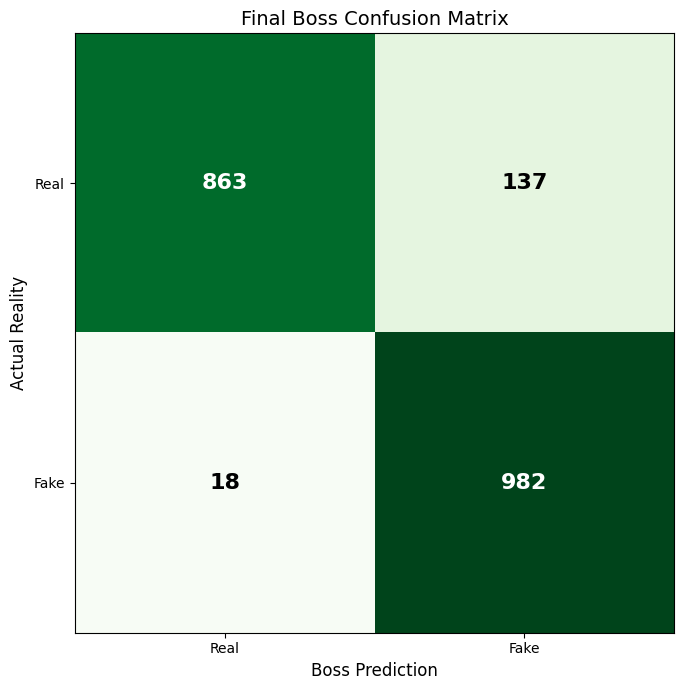


🎯 FINAL VALIDATION ACCURACY: 92.25%

📋 DETAILED REPORT:
              precision    recall  f1-score   support

        Real       0.98      0.86      0.92      1000
        Fake       0.88      0.98      0.93      1000

    accuracy                           0.92      2000
   macro avg       0.93      0.92      0.92      2000
weighted avg       0.93      0.92      0.92      2000



In [77]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import joblib
from PIL import Image
import torch
from tqdm import tqdm

# 1. SETUP & LOAD BOSS
boss = joblib.load('meta_learner_boss.joblib')
print("👔 Boss is ready for the BLIND VALIDATION test...")

def get_ensemble_scores(image_path):
    pil_img = Image.open(image_path).convert("RGB")
    
    # ViT Scores
    inputs = shared_processor(images=pil_img, return_tensors="pt")
    with torch.no_grad():
        v1_s = torch.nn.functional.softmax(model_v1(**inputs).logits, dim=-1)[0][0].item() * 100
        v2_s = torch.nn.functional.softmax(model_v2(**inputs).logits, dim=-1)[0][0].item() * 100
        
    # CNN Score
    cnn_input = preprocess_for_cnn(image_path)
    cnn_s = float(cnn_model.predict(cnn_input, verbose=0).flatten()[0]) * 100
    
    return [v1_s, v2_s, cnn_s]

# 2. COLLECT & SAMPLE DATA
val_images, val_labels = [], []
SAMPLE_SIZE = 1000 

for subfolder, label in [("Real", 0), ("Fake", 1)]:
    path = os.path.join("./Validation", subfolder)
    if os.path.exists(path):
        all_files = [os.path.join(path, f) for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Randomly sample up to 1000 images
        num_to_sample = min(len(all_files), SAMPLE_SIZE)
        sampled_files = random.sample(all_files, num_to_sample)
        
        val_images.extend(sampled_files)
        val_labels.extend([label] * num_to_sample)
        print(f"✅ Found {len(all_files)} {subfolder} images, sampled {num_to_sample}.")
    else:
        print(f"⚠️ Warning: Could not find folder {path}")

# 3. RUN INFERENCE WITH PROGRESS BAR
print(f"🧪 Starting validation on {len(val_images)} images...")
all_preds = []

# tqdm adds the progress bar!
for img_path in tqdm(val_images, desc="Analyzing Images"):
    try:
        scores = get_ensemble_scores(img_path)
        features = pd.DataFrame([scores], columns=['v1_fake_score', 'v2_fake_score', 'cnn_fake_score'])
        
        prob = boss.predict_proba(features)[0][1]
        all_preds.append(1 if prob > 0.5 else 0)
    except Exception as e:
        print(f"Error on {img_path}: {e}")
        # Remove corresponding label if image fails
        idx = val_images.index(img_path)
        val_labels.pop(idx)

# 4. PLOT CONFUSION MATRIX
cm = confusion_matrix(val_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens) # Green for growth!
ax.set_title('Final Boss Confusion Matrix', fontsize=14)

tick_marks = np.arange(2)
ax.set_xticks(tick_marks)
ax.set_xticklabels(['Real', 'Fake'])
ax.set_yticks(tick_marks)
ax.set_yticklabels(['Real', 'Fake'])

# Add counts inside the boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black",
                fontsize=16, fontweight='bold')

ax.set_ylabel('Actual Reality', fontsize=12)
ax.set_xlabel('Boss Prediction', fontsize=12)
plt.tight_layout()
plt.show()

# 5. PERFORMANCE SUMMARY
val_acc = accuracy_score(val_labels, all_preds) * 100
print(f"\n🎯 FINAL VALIDATION ACCURACY: {val_acc:.2f}%")
print("\n📋 DETAILED REPORT:")
print(classification_report(val_labels, all_preds, target_names=['Real', 'Fake']))

Testing Images and displaying metrics of each individual model in the ensemble/boss model

In [82]:
import os
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import joblib
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from transformers import AutoImageProcessor, AutoModelForImageClassification

# 1. OFFLINE SETUP & PATHS
os.environ['TRANSFORMERS_OFFLINE'] = '1'
os.environ['HF_HUB_OFFLINE'] = '1'

v1_abs_path = str(Path('vit_v1').resolve())
v2_abs_path = str(Path('vit_v2_final_model').resolve())

# 2. LOAD MODELS
print("⚙️ Loading the Ensemble for one final test...")
shared_processor = AutoImageProcessor.from_pretrained(v1_abs_path, local_files_only=True)
model_v1 = AutoModelForImageClassification.from_pretrained(v1_abs_path, local_files_only=True).eval()
model_v2 = AutoModelForImageClassification.from_pretrained(v2_abs_path, local_files_only=True).eval()
cnn_model = keras.models.load_model('deepfake_detector.keras')
boss = joblib.load('meta_learner_boss.joblib')

# 3. PREPROCESSING FUNCTION
def preprocess_for_cnn(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    return np.expand_dims(img_array, axis=0) # Raw pixels, no /255

# 4. FINAL PREDICTION LOGIC
def final_verdict(image_path):
    print(f"\n🔍 Analyzing: {os.path.basename(image_path)}")
    try:
        pil_img = Image.open(image_path).convert("RGB")
        
        # Get ViT Scores
        inputs = shared_processor(images=pil_img, return_tensors="pt")
        with torch.no_grad():
            v1_s = torch.nn.functional.softmax(model_v1(**inputs).logits, dim=-1)[0][0].item() * 100
            v2_s = torch.nn.functional.softmax(model_v2(**inputs).logits, dim=-1)[0][0].item() * 100
            
        # Get CNN Score
        cnn_input = preprocess_for_cnn(image_path)
        cnn_s = float(cnn_model.predict(cnn_input, verbose=0).flatten()[0]) * 100
        
        # The Boss Decides
        features = pd.DataFrame([[v1_s, v2_s, cnn_s]], columns=['v1_fake_score', 'v2_fake_score', 'cnn_fake_score'])
        final_prob = boss.predict_proba(features)[0][1] * 100
        
        verdict = "🚨 FAKE" if final_prob > 50 else "✅ REAL"
        confidence = final_prob if final_prob > 50 else 100 - final_prob
        
        print("--------------------------------------------------")
        print(f"V1 : {v1_s:.1f}% Fake")
        print(f"V2 : {v2_s:.1f}% Fake")
        print(f"CNN: {cnn_s:.1f}% Fake")
        print("--------------------------------------------------")
        print(f"VERDICT:  {verdict} (Confidence: {confidence:.1f}%)")
        print("--------------------------------------------------")
        
    except Exception as e:
        print(f"❌ Error processing image: {e}")

# ==========================================
# 5. TEST YOUR IMAGE HERE
# ==========================================
IMAGE_PATH = '/teamspace/studios/this_studio/deniszuccari_A_young_man_lounging_on_a_plush_cream-colored_sect_cd58ce01-7370-44d1-aea2-e45281fe3f8e.png'
final_verdict(IMAGE_PATH)

⚙️ Loading the Ensemble for one final test...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


🔍 Analyzing: deniszuccari_A_young_man_lounging_on_a_plush_cream-colored_sect_cd58ce01-7370-44d1-aea2-e45281fe3f8e.png
--------------------------------------------------
V1 : 63.8% Fake
V2 : 27.3% Fake
CNN: 26.9% Fake
--------------------------------------------------
VERDICT:  🚨 FAKE (Confidence: 55.8%)
--------------------------------------------------


In [84]:
import os
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import joblib
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from transformers import AutoImageProcessor, AutoModelForImageClassification

# 1. OFFLINE SETUP & PATHS
os.environ['TRANSFORMERS_OFFLINE'] = '1'
os.environ['HF_HUB_OFFLINE'] = '1'

v1_abs_path = str(Path('vit_v1').resolve())
v2_abs_path = str(Path('vit_v2_final_model').resolve())

# 2. LOAD MODELS
print("⚙️ Loading the Ensemble for one final test...")
shared_processor = AutoImageProcessor.from_pretrained(v1_abs_path, local_files_only=True)
model_v1 = AutoModelForImageClassification.from_pretrained(v1_abs_path, local_files_only=True).eval()
model_v2 = AutoModelForImageClassification.from_pretrained(v2_abs_path, local_files_only=True).eval()
cnn_model = keras.models.load_model('deepfake_detector.keras')
boss = joblib.load('meta_learner_boss.joblib')

# 3. PREPROCESSING FUNCTION
def preprocess_for_cnn(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    return np.expand_dims(img_array, axis=0) # Raw pixels, no /255

# 4. FINAL PREDICTION LOGIC
def final_verdict(image_path):
    print(f"\n🔍 Analyzing: {os.path.basename(image_path)}")
    try:
        pil_img = Image.open(image_path).convert("RGB")
        
        # Get ViT Scores
        inputs = shared_processor(images=pil_img, return_tensors="pt")
        with torch.no_grad():
            v1_s = torch.nn.functional.softmax(model_v1(**inputs).logits, dim=-1)[0][0].item() * 100
            v2_s = torch.nn.functional.softmax(model_v2(**inputs).logits, dim=-1)[0][0].item() * 100
            
        # Get CNN Score
        cnn_input = preprocess_for_cnn(image_path)
        cnn_s = float(cnn_model.predict(cnn_input, verbose=0).flatten()[0]) * 100
        
        # The Boss Decides
        features = pd.DataFrame([[v1_s, v2_s, cnn_s]], columns=['v1_fake_score', 'v2_fake_score', 'cnn_fake_score'])
        final_prob = boss.predict_proba(features)[0][1] * 100
        
        verdict = "🚨 FAKE" if final_prob > 50 else "✅ REAL"
        confidence = final_prob if final_prob > 50 else 100 - final_prob
        
        print("--------------------------------------------------")
        print(f"V1 : {v1_s:.1f}% Fake")
        print(f"V2 : {v2_s:.1f}% Fake")
        print(f"CNN: {cnn_s:.1f}% Fake")
        print("--------------------------------------------------")
        print(f"VERDICT:  {verdict} (Confidence: {confidence:.1f}%)")
        print("--------------------------------------------------")
        
    except Exception as e:
        print(f"❌ Error processing image: {e}")

# ==========================================
# 5. TEST YOUR IMAGE HERE
# ==========================================
IMAGE_PATH = '/teamspace/studios/this_studio/IMG_0352 2.WEBP'
final_verdict(IMAGE_PATH)

⚙️ Loading the Ensemble for one final test...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


🔍 Analyzing: IMG_0352 2.WEBP
--------------------------------------------------
V1 : 67.8% Fake
V2 : 10.9% Fake
CNN: 4.9% Fake
--------------------------------------------------
VERDICT:  ✅ REAL (Confidence: 72.6%)
--------------------------------------------------


Worse performance, performaing bad as observed in test data 

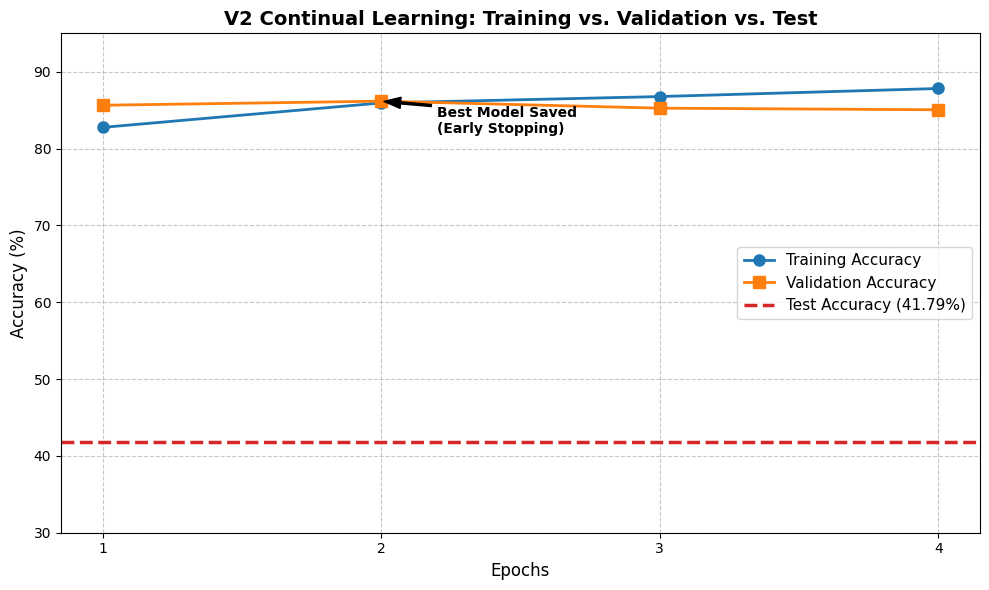

In [85]:
import matplotlib.pyplot as plt

# 1. DATA (Extracted from screenshots and previous logs)
epochs = [1, 2, 3, 4]
train_acc = [82.76, 85.94, 86.77, 87.82]
val_acc = [85.64, 86.17, 85.26, 85.05]

# Using the V2 Test Accuracy from your prior ensemble evaluation
test_acc = 41.79 

# 2. PLOT SETUP
plt.figure(figsize=(10, 6))

# Plot Training and Validation as lines
plt.plot(epochs, train_acc, label='Training Accuracy', color='#1f77b4', marker='o', linewidth=2, markersize=8)
plt.plot(epochs, val_acc, label='Validation Accuracy', color='#ff7f0e', marker='s', linewidth=2, markersize=8)

# Plot Test Accuracy as a horizontal baseline for comparison
plt.axhline(y=test_acc, color='#d62728', linestyle='--', linewidth=2.5, label=f'Test Accuracy ({test_acc}%)')

# 3. ANNOTATIONS
# Mark where the best model was saved (Epoch 2 based on your logs)
plt.annotate('Best Model Saved\n(Early Stopping)', xy=(2, 86.17), xytext=(2.2, 82),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, fontweight='bold', ha='left')

# 4. FORMATTING
plt.title('V2 Continual Learning: Training vs. Validation vs. Test', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epochs)
plt.ylim(30, 95) # Scaled to show the massive gap between Train/Val and actual Test
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='center right', fontsize=11)

# 5. SHOW GRAPH
plt.tight_layout()
plt.show()

Fine Tuning VIT V2 Model to improve Midjourney Performance below

In [91]:

import os
import zipfile
!pip install kaggle -q

# 1. SET UP KAGGLE
os.environ['KAGGLE_API_TOKEN'] = "KGAT_1484455f88b2dddd50048f04f91de4c0"
RAW_DATA_DIR = "./Kaggle_Raw_Data"

def download_kaggle_data(url, folder_name):
    if "PASTE" in url:
        print(f"❌ STOP: You need to paste the Kaggle URL for {folder_name}!")
        return
        
    # Extracts the exact dataset name from your URL
    slug = url.split("datasets/")[-1].strip("/")
    download_path = os.path.join(RAW_DATA_DIR, folder_name)
    os.makedirs(download_path, exist_ok=True)
    
    print(f"📥 Pulling dataset from Kaggle: {slug}...")
    os.system(f"kaggle datasets download -d {slug} -p {download_path}")
    
    zip_name = slug.split('/')[-1] + ".zip"
    zip_path = os.path.join(download_path, zip_name)
    
    if os.path.exists(zip_path):
        print(f"📦 Extracting {zip_name}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(download_path)
        os.remove(zip_path)
        print(f"✅ Success! Data saved in {download_path}\n")
    else:
        print(f"⚠️ Failed to download. Check if the URL is correct: {url}\n")

# ==========================================
# 2. PASTE YOUR URLS HERE
# ==========================================
# I pre-filled the CIPLAB dataset. Just grab the URL for the Midjourney dataset you want to use!
URL_40K_DATASET = "https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection"
URL_MIDJOURNEY  = "https://www.kaggle.com/datasets/superpotato9/dalle-recognition-dataset" 

# ==========================================
# 3. RUN DOWNLOAD
# ==========================================
download_kaggle_data(URL_40K_DATASET, "40k_data")
download_kaggle_data(URL_MIDJOURNEY, "midjourney_data")

# Show the downloaded folders so we can verify it worked
print("\n📂 Downloaded Folder Structure:")
os.system(f"ls -la {RAW_DATA_DIR}")

📥 Pulling dataset from Kaggle: ciplab/real-and-fake-face-detection...
Dataset URL: https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection
License(s): CC-BY-NC-SA-4.0


100%|██████████| 431M/431M [00:07<00:00, 63.1MB/s] 



📦 Extracting real-and-fake-face-detection.zip...
✅ Success! Data saved in ./Kaggle_Raw_Data/40k_data

📥 Pulling dataset from Kaggle: superpotato9/dalle-recognition-dataset...
Dataset URL: https://www.kaggle.com/datasets/superpotato9/dalle-recognition-dataset
License(s): MIT


100%|██████████| 13.4G/13.4G [02:00<00:00, 120MB/s] 



📦 Extracting dalle-recognition-dataset.zip...
✅ Success! Data saved in ./Kaggle_Raw_Data/midjourney_data


📂 Downloaded Folder Structure:
total 20
drwxr-xr-x 4 remu1708 remu1708 4096 Apr 11 09:50 .
drwxr-xr-x 1 remu1708 remu1708 4096 Apr 11 09:50 ..
drwxr-xr-x 4 remu1708 remu1708 4096 Apr 11 09:55 40k_data
drwxr-xr-x 4 remu1708 remu1708 4096 Apr 11 09:59 midjourney_data


0

Loading images for Fine tuning V2 one last time

In [93]:
import os

print("📂 Inside 40k_data:")
os.system("ls -la ./Kaggle_Raw_Data/40k_data")

print("\n📂 Inside midjourney_data:")
os.system("ls -la ./Kaggle_Raw_Data/midjourney_data")

📂 Inside 40k_data:
total 16
drwxr-xr-x 4 remu1708 remu1708 4096 Apr 11 09:55 .
drwxr-xr-x 4 remu1708 remu1708 4096 Apr 11 09:50 ..
drwxr-xr-x 4 remu1708 remu1708 4096 Apr 11 09:53 real_and_fake_face
drwxr-xr-x 3 remu1708 remu1708 4096 Apr 11 09:53 real_and_fake_face_detection

📂 Inside midjourney_data:
total 132
drwxr-xr-x 4 remu1708 remu1708   4096 Apr 11 09:59 .
drwxr-xr-x 4 remu1708 remu1708   4096 Apr 11 09:50 ..
drwxr-xr-x 3 remu1708 remu1708   4096 Apr 11 09:57 fakeV2
drwxr-xr-x 2 remu1708 remu1708 122880 Apr 11 09:59 real


0

Creating Fine tuned V2 model and training exlusively on midjourney images in hopes of improved performance. Previously trained weights may have been lost due to catastrophic forgetting.

In [97]:
import os
import random
import shutil
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import (
    AutoImageProcessor, 
    AutoModelForImageClassification, 
    TrainingArguments, 
    Trainer,
    DefaultDataCollator
)

RAW_DATA_DIR = "./Kaggle_Raw_Data"
MIXED_DIR = "./Mixed_Training_Data"
os.environ['WANDB_DISABLED'] = 'true'

# ==========================================
# 1. SMART PATH FINDER
# ==========================================
def get_image_folder(base_path, keyword):
    for root, dirs, files in os.walk(base_path):
        if keyword in os.path.basename(root).lower() and any(f.lower().endswith(('.png', '.jpg', '.jpeg')) for f in files):
            return root
    return base_path 

PATH_40K_REAL = get_image_folder(f"{RAW_DATA_DIR}/40k_data", "real")
PATH_40K_FAKE = get_image_folder(f"{RAW_DATA_DIR}/40k_data", "fake")
# Point to the top of midjourney data, we will let the new copy function dig for it
PATH_MIDJOURNEY = f"{RAW_DATA_DIR}/midjourney_data/fakeV2" 

# ==========================================
# 2. BUILD THE MIXED DATASET (Deep Search)
# ==========================================
print("🔄 Building the Mixed Dataset...")
if os.path.exists(MIXED_DIR):
    shutil.rmtree(MIXED_DIR)

os.makedirs(f"{MIXED_DIR}/Real", exist_ok=True)
os.makedirs(f"{MIXED_DIR}/Fake", exist_ok=True)

def sample_and_copy_deep(src_folder, dest_folder, sample_size):
    if not os.path.exists(src_folder):
        print(f"⚠️ Missing folder: {src_folder}. Skipping.")
        return
    
    # This drills down into ALL subfolders to find the images
    all_images = []
    for root, _, files in os.walk(src_folder):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                all_images.append(os.path.join(root, f))
                
    if not all_images:
        print(f"⚠️ No images found anywhere inside {src_folder}!")
        return
    
    sampled = random.sample(all_images, min(len(all_images), sample_size))
    for img_path in sampled:
        shutil.copy(img_path, os.path.join(dest_folder, os.path.basename(img_path)))
        
    print(f"✅ Mixed {len(sampled)} images from {os.path.basename(src_folder)} into {os.path.basename(dest_folder)}")

# Mix: 1000 Real, 500 GAN Fakes, 500 Diffusion Fakes
sample_and_copy_deep(PATH_40K_REAL, f"{MIXED_DIR}/Real", 1000)
sample_and_copy_deep(PATH_40K_FAKE, f"{MIXED_DIR}/Fake", 500)
sample_and_copy_deep(PATH_MIDJOURNEY, f"{MIXED_DIR}/Fake", 500)

# ==========================================
# 3. LOAD DATASET & PROCESSOR
# ==========================================
print("\n⚙️ Loading V2 Model & Data...")
dataset = load_dataset("imagefolder", data_dir=MIXED_DIR, split="train")
dataset = dataset.train_test_split(test_size=0.2) 

model_path = "./vit_v2_final_model" 
processor = AutoImageProcessor.from_pretrained(model_path, local_files_only=True)
model = AutoModelForImageClassification.from_pretrained(
    model_path, 
    num_labels=2, 
    ignore_mismatched_sizes=True, 
    local_files_only=True
)

def transforms(examples):
    inputs = processor([img.convert("RGB") for img in examples["image"]], return_tensors="pt")
    inputs["labels"] = examples["label"]
    return inputs

processed_dataset = dataset.with_transform(transforms)

# ==========================================
# 4. TRAINER SETUP & FAST TRAINING
# ==========================================
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./vit_v2_generalist",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,          
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,          
    weight_decay=0.01,
    load_best_model_at_end=True,
    fp16=True,                   
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=processed_dataset["train"],
    eval_dataset=processed_dataset["test"],
    # tokenizer=processor,  <--- WE DELETED THIS LINE
    data_collator=DefaultDataCollator(),
    compute_metrics=compute_metrics,
)

print("\n🚀 Starting Fast Mixed Training...")
trainer.train()

# Save both the model and the processor so they work together later!
trainer.save_model("./vit_generalist_final")
processor.save_pretrained("./vit_generalist_final")

print("\n🎉 DONE! Saved the Ultimate 'Generalist' model to './vit_generalist_final'")

🔄 Building the Mixed Dataset...


✅ Mixed 1000 images from training_real into Real
✅ Mixed 500 images from training_fake into Fake
✅ Mixed 500 images from fakeV2 into Fake

⚙️ Loading V2 Model & Data...


Resolving data files:   0%|          | 0/2000 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 DONE! Saved the Ultimate 'Generalist' model to './vit_generalist_final'


Based on trainnig logs, the sudden decrease in training loss suggest model is overfitting. This may result in hallucinations and wrong predictions. Hence to conclude, the CNN is the best performing model among all 3 model and is able to detect STYLEGAN images easily. the V1 Vision Transformer is way better at detecting midjoureny images and other so images but not to the capability of the CNN. This proves the vision transformer is the state of the art for Machine vision applications, depeing upon tasks CNN may prove to be superior.